Given $Eu$ has no net electronic spin we have a slightly different spin Hamiltonian
$$H = \underbrace{\mu_{n}\times B\times g_{n}\times I}_{\textrm{Nuclear Zeeman}}+\underbrace{I\times Q\times I}_{Quadrupole}$$

As per [Longdell et. al.](10.1103/PhysRevB.74.195101). This work focuses on $Pr$, with $\frac{5}{2}$ nuclear spin, that sits in a $C_{1}$ symmetry site. Note the work uses $B\times M\times I$ for its nuclear zeeman terms so we will divide M by the nuclear magneton.

In [1]:
import numpy as np
import spin_hamiltonian as spin
from scipy.spatial.transform import Rotation
import scipy.linalg as la
import matplotlib.pyplot as plt
import matplotlib.colors as clr
from copy import deepcopy
import sys
from matplotlib.patches import Rectangle
from scipy.sparse.linalg import inv as spinv
from scipy.sparse import block_diag

In [2]:
plt.rc('xtick', labelsize=16) 
plt.rc('ytick', labelsize=16) 
plt.rc('axes',labelsize=20)
plt.rc('axes',titlesize=20)

In [3]:
#spin Operators of Eu:YSO:
Espin = 0#1/2
Ispin = 5/2

muNf = 7.622593285 #MHz/T
#muNf*=(1E6/1E4)*1E-3 #kHz/G

#Initialise the class with its electronic and nuclear spin, for both ground and excited state
ground = spin.cSpinHamiltonian(Espin,Ispin)

print(ground.I.shape)
print(ground.Idim,ground.Edim,ground.dim)
print(muNf)

(36, 3)
6 1 6
7.622593285


In [4]:
#M tensor ground state
M = np.matrix(np.diag([2.86,3.05,11.56]))*10/muNf#*muNf#*1E-4#/muNf#*1E-1#*spin.h*spin.muN
#Q tensor ground state
Q = np.matrix(np.diag([-0.5624,0.5624,4.4450]))*1E6*spin.h #MHz*h

print(Q/(1E6*spin.h))
eRot= 'ZYZ'

#rotated tensors
M_rot = np.array([-99.7,55.7,-40])*np.pi/180
Q_rot = np.array([-94,58.1,-20.7])*np.pi/180

M_G = spin.tensorRotation(M,M_rot,str=eRot)#ZYZ
Q_G = spin.tensorRotation(Q,Q_rot,str=eRot)

print('Q',Q_G/(1E6*spin.h))
print('M',M_G)
#Initialise the static quadrapole interaction
ground.quadrupoleInteraction(Q_G)
#ground.setM(M_G)

az = -2.1
alt = 0#(90-87.8)
rt = np.array([alt,az])*np.pi/180
RB = spin.sphereUnit(rt,unit=False,str='zy')

M_G=RB@M_G@RB.T


ground.setgN(M_G)
#print(ground.H.shape)

[[-0.5624  0.      0.    ]
 [ 0.      0.5624  0.    ]
 [ 0.      0.      4.445 ]]
Q [[ 0.40747302 -0.00924087 -0.46728936]
 [-0.00924087  3.10033234 -2.15607217]
 [-0.46728936 -2.15607217  0.93719464]]
M [[ 4.09319568  1.2094972  -0.98709479]
 [ 1.2094972  11.37875701 -5.17297102]
 [-0.98709479 -5.17297102  7.44675667]]


-10.187833639634666 -17.310310645043373


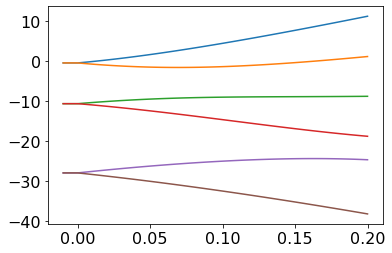

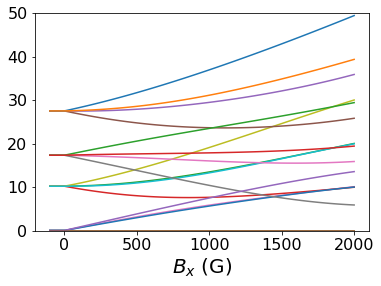

In [5]:
#Zero Field
from scipy.spatial.transform import Rotation


 #convert spherical Magnetic field to cartesian coords.
#print(np.zeros(20),np.linspace(0,0.2,100))
#theta,phi = spin.eulerToSphere(Q_rot,str='ZXZ')
#RM = Rotation.from_euler('yz',[theta,phi]).as_matrix()
RM = np.asmatrix(Rotation.from_euler(eRot,-M_rot).as_matrix())
#RM=spin.rotMatrixDumb(M_rot)
#print(RM)

#print(RB)

xs = np.concatenate((np.zeros(20),np.linspace(0,0.2,100)))
#xs = np.zeros(20)
#print(x)
#print(B)
#Calculate our hamiltonian at this B Field

F=np.zeros((len(xs),ground.dim))

for i,x in enumerate(xs):
    B = np.matrix([x,0,0]).T
    #print(B)
    #B=RM@B
    #convert spherical Magnetic field to cartesian coords.
    #B =RB@B
    #B=spin.sphereCart(x,*rt)
    #print(B)
            
    HG = ground.H+ground.nuclearZeeman(B)#/spin.muN
    #get the eigen frequencies and vectors at this B field
    FG,VG = ground.getEigFreq(HG)
    F[i,:]=FG*1E3

#x = 

#print(F[0][])
print(F[0][2]-F[0][0],F[0][4]-F[0][2])

xs[0:20]=np.linspace(-0.01,0,20)

#
plt.plot(xs,F)
plt.show()
plt.close()

plt.plot(xs*1E4,spin.eachElemFunc(F,F,ax=1))
plt.ylim([0,50])
plt.xlabel("$B_{x}$ (G)")
plt.savefig("Pr.png")
plt.show()
plt.close()

# ZEFOZ notes:
Critical points occur when:
$$\frac{\partial f_{nm}}{\partial B_{i}} = \left<\psi_{n}\right|A_{i}\left|\psi_{m}\right>=0$$

Our sensitivity is the extension:
$$\vec{S}_{1} = \frac{\partial f_{nm}}{\partial B_{x}}\vec{i}+\frac{\partial f_{nm}}{\partial B_{y}}\vec{j}+\frac{\partial f_{nm}}{\partial B_{z}}\vec{k}$$

Maximum curvature given by the largest eigenvalue of $S_{2}$
$$\vec{S}_{2} = \begin{pmatrix}\frac{\partial^2 f}{\partial B_{x}\partial B_{x}}&\frac{\partial^2 f}{\partial B_{x}\partial B_{y}}&\frac{\partial^2 f}{\partial B_{x}\partial B_{z}}\\\frac{\partial^2 f}{\partial B_{y}\partial B_{x}}&\frac{\partial^2 f}{\partial B_{y}\partial B_{y}}&\frac{\partial^2 f}{\partial B_{y}\partial B_{z}}\\\frac{\partial^2 f}{\partial B_{z}\partial B_{x}}&\frac{\partial^2 f}{\partial B_{z}\partial B_{y}}&\frac{\partial^2 f}{\partial B_{z}\partial B_{z}}\end{pmatrix}$$

Where
$$\frac{\partial^2 f}{\partial B_{i}\partial B_{j}} =\sum_{m\neq n}\frac{1}{f_{n}-f_{m}}\left[\left<\psi_{m}\right|A_{i}\left|\psi_{n}\right>\left<\psi_{n}\right|A_{j}\left|\psi_{m}\right>+c.c.\right]+G_{i,j}+G_{j,i} $$

This gives our $T_{2}$ time at a ZEFOZ point:
$$\frac{1}{\pi T_{2}} = \vec{S}_{1}\cdot\Delta\vec{B}+\Delta\vec{B}\cdot\vec{S}_{2}\cdot\Delta\vec{B}$$

In [6]:

#
Is = spin.spinOperator(Ispin,matricies=True)
As = spin.genAMatrix(spin.muN*M_G,Is)

def singleLoop(X,Y,Z):
    #convert spherical Magnetic field to cartesian coords.
    B = np.matrix([X,Y,Z]).T
    
    #Calculate our hamiltonian at this B Field
    HG = ground.H+ground.nuclearZeeman(B)#/spin.muN

    #get the eigen frequencies and vectors at this B field
    FG,VG = ground.getEigFreq(HG)
    F=FG*1E3
    
    Fp = []
    #OS = np.zeros((ground.dim,3),dtype = np.csingle)
    for l in range(3):
        v = ground.firstOrderEnergySensitivity(VG,As[l]/spin.muN)*spin.muN
        Fp.append(v)
    Fp = np.array(Fp).T
    Fpp = ground.curvatureCalculation(As[0],As[1],As[2],VG,FG,indiv=False).T#*spin.muN
    #Fpp = ground.curvatureCalculationNaive(As[0],As[1],As[2],VG,FG,indiv=False).T#*spin.muN
    
    return (F,Fp,Fpp)

def singleLoopNoCurve(X,Y,Z):
    #convert spherical Magnetic field to cartesian coords.
    B = np.matrix([X,Y,Z]).T
    
    #Calculate our hamiltonian at this B Field
    HG = ground.H+ground.nuclearZeeman(B)#/spin.muN

    #get the eigen frequencies and vectors at this B field
    FG,VG = ground.getEigFreq(HG)
    F=FG*1E3
    
    Fp = []
    #OS = np.zeros((ground.dim,3),dtype = np.csingle)
    for l in range(3):
        v = ground.firstOrderEnergySensitivity(VG,As[l]/spin.muN)*spin.muN
        Fp.append(v)
    Fp = np.array(Fp).T
    #Fpp = ground.curvatureCalculation(As[0],As[1],As[2],VG,FG,indiv=False).T#*spin.muN
    #Fpp = ground.curvatureCalculationNaive(As[0],As[1],As[2],VG,FG,indiv=False).T#*spin.muN
    
    return (F,Fp)




#our loop
def sweep(Bs):
    #sets the default dynamic term as both electronic and nuclear zeeman
    #F = ground.initSweep(Bx,By,Bz)
    #Fp = np.zeros((len(Bx),len(By),len(Bz),ground.dim,3),dtype = np.csingle)#
    #Fp=ground.initSweep(Bx,By,Bz,[ground.dim,3])
    ##Fpp = ground.initSweep(Bx,By,Bz,ground.dim)
    #Fpp = ground.initSweep(Bx,By,Bz,fdim=[ground.dim,3,3])
    F=np.zeros((len(Bs),ground.dim))
    Fp=np.zeros((len(Bs),ground.dim,3),dtype = np.csingle)
    Fpp=np.zeros((len(Bs),ground.dim,3,3),dtype = np.csingle)

    for i in range(Bs.shape[0]):
        F[i,:],Fp[i,:],Fpp[i,:] = singleLoop(Bs[i,0],Bs[i,1],Bs[i,2])
    #return all transion based values         
    return spin.eachElemFunc(F,F,ax=1),spin.eachElemFunc(Fp,Fp,ax=1),spin.eachElemFunc(Fpp,Fpp,ax=1)
    #return F,Fp,Fpp

def sweepNoCurve(Bs):
    #sets the default dynamic term as both electronic and nuclear zeeman
    #F = ground.initSweep(Bx,By,Bz)
    #Fp = np.zeros((len(Bx),len(By),len(Bz),ground.dim,3),dtype = np.csingle)#
    #Fp=ground.initSweep(Bx,By,Bz,[ground.dim,3])
    ##Fpp = ground.initSweep(Bx,By,Bz,ground.dim)
    #Fpp = ground.initSweep(Bx,By,Bz,fdim=[ground.dim,3,3])
    F=np.zeros((len(Bs),ground.dim))
    Fp=np.zeros((len(Bs),ground.dim,3),dtype = np.csingle)
    
    for i in range(Bs.shape[0]):
        F[i,:],Fp[i,:] = singleLoopNoCurve(Bs[i,0],Bs[i,1],Bs[i,2])
    #return all transion based values         
    return spin.eachElemFunc(F,F,ax=1),spin.eachElemFunc(Fp,Fp,ax=1)


def printRegionsXY(CR):
    for R in CR:
        #print(R)
        h=R[1][1]-R[1][0]
        w = R[0][1]-R[0][0]
        #print(R[0:1][0],w,h)
        ax=plt.gca()
        ax.add_patch(Rectangle([R[0][0],R[1][0]],w,h,fill=False))


def NewtonMethodStep(B,Fp,Fpp,i,gamma=2,th=1E4):
    B = B.reshape(1,-1).T
    V = Fp[:,i,:].reshape(1,-1).T
    S = np.linalg.inv(Fpp[:,i,:,:])
    C=np.abs(block_diag(S))    
    newB = B-gamma*C@V
    #print(newB)
    newB = newB.T.reshape(-1,3)
    #print(newB)
    bad = np.argwhere(np.any(np.abs(newB)>th,axis=1))
    #print("Newton", newB)
    print(np.squeeze(bad))
    newB = np.delete(newB,np.squeeze(bad),axis=0)

        
    return newB

def GradientDescentStep(B,Fp,i,gamma=2,th=1E4):
    B = B.reshape(1,-1).T
    V = np.real(Fp[:,i,:].reshape(1,-1).T)
    newB = B-gamma*V
    #print(newB)
    newB = newB.T.reshape(-1,3)
    #print(newB)
    bad = np.argwhere(np.any(np.abs(newB)>1E4,axis=1))
    #print("Newton", newB)
    print(np.squeeze(bad))
    newB = np.delete(newB,np.squeeze(bad),axis=0)

        
    return newB

In [7]:
np.set_printoptions(threshold=np.inf)

pts = 10

ps=-0.2
pe = 0.2

Bxi = np.linspace(ps,pe,pts)
Byi = Bxi
Bzi = Bxi

Bx,By,Bz = np.meshgrid(Bxi,Byi,Bzi)
Bsi = np.array(np.meshgrid(Bxi,Byi,Bzi)).reshape(3,-1).T
#delta = (Bxi[-1]-Bxi[0])/len(Bxi)
Bs=Bsi

Fi,Fip,Fipp=sweep(Bs)

print(Fi.shape)
print(Fip.shape)
print(Fipp.shape)
#print(Fipp[:,10,:,:])

Idi = spin.ZEFOZidx(Fip.reshape(pts,pts,pts,ground.dim**2,3))
t=3

#print(Idi.shape)
ZFidx = Idi[np.where(Idi[:,3]==t)]
#print(ZFidx)
BZP = np.array([Bxi[ZFidx[:,0]],Byi[ZFidx[:,1]],Bzi[ZFidx[:,2]]]).T
#np.array(np.meshgrid(Bxi,Byi,Bzi)).reshape(3,-1).T
print(BZP*1E4)
#Bs = NewtonMethodStep(Bs,Fip,Fipp,t,gamma=1)
#F,Fp,Fpp=sweep(Bs)

#print(np.real(Fipp))
#plt.pcolor(Bxi,Byi,np.real(Fi[:,t].reshape(pts,pts)).T,cmap='nipy_spectral',shading='auto')
#plt.legend()
#plt.plot(Bx[:,:,0],By[:,:,0],'b.')
#plt.plot(Bs[:,0],Bs[:,1],'*')
# plt.colorbar()

# #plt.plot(Bxi,Fi[:,t],'*-')
# #

# plt.xlim([-5,5])
# plt.ylim([-5,5])
# plt.show()
# plt.close()

#print(Bs)


c:\Users\neb16\Documents\Uni\PHD\Experiments\Simulations\Spin_Hamiltonian\spin_hamiltonian\spin_hamiltonian.py:310: RuntimeWarning: divide by zero encountered in true_divide
  Sgn =np.nan_to_num(1/(E[a]-E[b]).reshape(self.dim,self.dim),posinf=0,nan=0,neginf=0)


(1000, 36)
(1000, 36, 3)
(1000, 36, 3, 3)
[[-2000.          -222.22222222 -1111.11111111]
 [-1555.55555556  -222.22222222 -1111.11111111]
 [-1555.55555556  -222.22222222  -666.66666667]
 [-1555.55555556   222.22222222 -1111.11111111]
 [-1555.55555556   666.66666667  -222.22222222]
 [-1111.11111111  -222.22222222 -2000.        ]
 [-1111.11111111  -222.22222222 -1111.11111111]
 [-1111.11111111  -222.22222222  -666.66666667]
 [-1111.11111111   222.22222222 -1111.11111111]
 [-1111.11111111   222.22222222  -666.66666667]
 [-1111.11111111   222.22222222   222.22222222]
 [ -666.66666667  -222.22222222 -2000.        ]
 [ -666.66666667  -222.22222222 -1555.55555556]
 [ -666.66666667  -222.22222222 -1111.11111111]
 [ -666.66666667  -222.22222222  -666.66666667]
 [ -666.66666667  -222.22222222   666.66666667]
 [ -666.66666667   222.22222222 -1111.11111111]
 [ -666.66666667   222.22222222  -666.66666667]
 [ -666.66666667   222.22222222   222.22222222]
 [ -666.66666667   222.22222222   666.66666667

[]
0
[]
1
[]
2
[]
3
[]
4
[]
5
[]
6
[]
7
[]
8
[]
9
[]
10
[]
11
[]
12
[]
13
[]
14
[]
15
[]
16
[]
17
[]
18
[]
19
[]
20
[]
21
[]
22
[]
23
[]
24
[]
25
[]
26
[]
27
[]
28
[]
29
[]
30
[]
31
[]
32
[]
33
[]
34
[]
35
[]
36
[]
37
[]
38
[]
39
[]
40
[]
41
[]
42
[]
43
[]
44
[]
45
[]
46
[]
47
[]
48
[]
49
[]
50
[]
51
[]
52
[]
53
[]
54
[]
55
[]
56
[]
57
[]
58
[]
59
[]
60
[]
61
[]
62
[]
63
[]
64
[]
65
[]
66
[]
67
[]
68
[]
69
[]
70
[]
71
[]
72
[]
73
[]
74
[]
75
[]
76
[]
77
[]
78
[]
79
[]
80
[]
81
[]
82
[]
83
[]
84
[]
85
[]
86
[]
87
[]
88
[]
89
[]
90
[]
91
[]
92
[]
93
[]
94
[]
95
[]
96
[]
97
[]
98
[]
99
[]
100
[]
101
[]
102
[]
103
[]
104
[]
105
[]
106
[]
107
[]
108
[]
109
[]
110
[]
111
[]
112
[]
113
[]
114
[]
115
[]
116
[]
117
[]
118
[]
119
[]
120
[]
121
[]
122
[]
123
[]
124
[]
125
[]
126
[]
127
[]
128
[]
129
[]
130
[]
131
[]
132
[]
133
[]
134
[]
135
[]
136
[]
137
[]
138
[]
139
[]
140
[]
141
[]
142
[]
143
[]
144
[]
145
[]
146
[]
147
[]
148
[]
149
[]
150
[]
151
[]
152
[]
153
[]
154
[]
155
[]
156
[]
157
[]
1

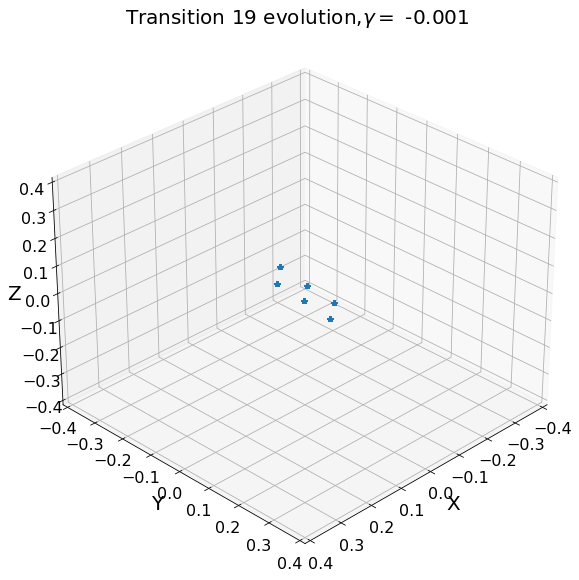

In [8]:

from matplotlib import animation
from functools import partial
#from mpl_toolkits.mplot3d import Axes3D

fig=plt.figure(figsize=(10,10))
#ax = plt.axes()
#fig, ax = plt.subplots()
ax=fig.add_subplot(projection='3d')
#bg = ax.pcolor(Bx[:,:,0],By[:,:,0],np.real(Fi[:,t].reshape(pts,pts)).T,cmap='nipy_spectral',shading='auto')
#pe*=1E4
zpts,=ax.plot([],[],[],'*')
ax.set(xlim3d=(-2*pe, 2*pe), xlabel='X')
ax.set(ylim3d=(-2*pe, 2*pe), ylabel='Y')
ax.set(zlim3d=(-2*pe, 2*pe), zlabel='Z')
ax.view_init(azim=45, elev=30)
##pts=ax.plot()

#plt.legend()
#plt.plot(,'b.')
#bg.colorbar()
S = 2E-0
F = 1E-3
frames = 300
tau = -frames/np.log(F/S)
tauo = frames/np.log(S-F+1)
m=(F-S)/-frames
#frames = 200
t=19
ax.set(title="Transition %s evolution"%t)


SA = lambda f: S*np.exp(-f/tau)
SAo = lambda f: (S-np.exp(f/tauo)+1)
SAl =lambda f: S-m*f
#plt.plot(Bxi,Fi[:,t],'*-')
#
global Bf
#Bsi = 
Bf=np.array(np.meshgrid(Bxi,Byi,Bzi)).reshape(3,-1).T
#Bf=BZP

def init():
    #pass
    #ax.set_xlim(-5,5)
    #ax.set_ylim(-5,5)
    #zpts,=ax.plot([],[],'*')
    zpts.set_data(Bf[:,0],Bf[:,1])
    zpts.set_3d_properties(Bf[:,2])

    #pts.set_data(Bf[:,0],Bf[:,1]) 
    return zpts,

def update(frame):
    global Bf
    g=-SA(frame)
    ax.set(title="Transition %s evolution,$\gamma=$ %s"%(t,np.around(g,3)))

    zpts.set_data(Bf[:,0],Bf[:,1])
    zpts.set_3d_properties(Bf[:,2])
    #F,Fp,Fpp=sweep(Bf)
    F,Fp=sweepNoCurve(Bf)
    #Bf = NewtonMethodStep(Bf,Fp,Fpp,t,gamma=0.01)
    Bf=GradientDescentStep(Bf,Fp,t,gamma=g)
    print(frame)
    return zpts,

ani=animation.FuncAnimation(fig,update,init_func=init,blit=True,frames=frames,interval=1)
ani.save('test.mp4', fps=30)

#plt.show()
#plt.close()



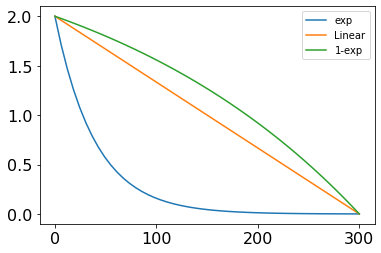

In [9]:
#plt.close()
fs = np.linspace(0,frames)
plt.plot(fs,SA(fs),label="exp")
plt.plot(fs,SAl(fs),label="Linear")
plt.plot(fs,SAo(fs),label="1-exp")
plt.legend()
plt.show()
plt.close()

ZEFOZ points:  [[ -550.   290. -1100.]
 [ -370.  -420.  -720.]
 [ -210. -1160.  -390.]
 [  210.  1160.   390.]
 [  370.   420.   720.]
 [  550.  -290.  1100.]]
0.11
(10000, 3)


c:\Users\neb16\Documents\Uni\PHD\Experiments\Simulations\Spin_Hamiltonian\spin_hamiltonian\spin_hamiltonian.py:310: RuntimeWarning: divide by zero encountered in true_divide
  Sgn =np.nan_to_num(1/(E[a]-E[b]).reshape(self.dim,self.dim),posinf=0,nan=0,neginf=0)


0.11
Ft (10000, 36)
Fr (100, 100)
(10, 10, 10) (10, 10, 10)


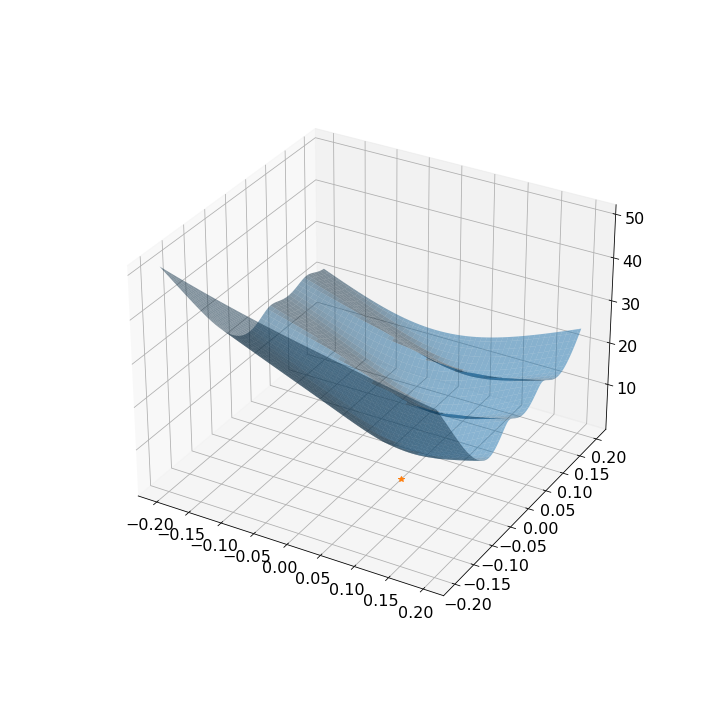

In [14]:
%matplotlib widget
#print(Bzi)

ZFP = np.unique(np.around(Bf,3),axis=0)

print("ZEFOZ points: ",ZFP*1E4)

idx=-1

z=ZFP[idx][2]#np.argwhere(Bzi==-4)
y=ZFP[idx][1]#np.argwhere(Bzi==-4)

print(z)

pts = 100
Bxi = np.linspace(-0.2,0.2,pts)
X,Y = np.meshgrid(Bxi,Bxi)
Bsi = np.array(np.meshgrid(Bxi,Bxi,z)).reshape(3,-1).T
print(Bsi.shape)
Ft,_,_=sweep(Bsi)


print(z)
print("Ft",Ft.shape)
fr = np.squeeze(np.real(Ft[:,t].T.reshape(pts,pts,-1)))
print("Fr",fr.shape)
print(Bx.shape,By.shape)
#plt.pcolor(Bxi,Byi,fr[:,:,1],cmap='nipy_spectral',shading='auto')
#plt.plot()
#print(BZP)


fig=plt.figure(figsize=(10,10))
#ax = plt.axes()
#fig, ax = plt.subplots()
ax=fig.add_subplot(projection='3d')
ax.plot_surface(X,Y,np.real(fr),alpha=0.5)
ax.plot(*ZFP[idx],'*')
plt.show()
#plt.close()


Fr (100, 100)


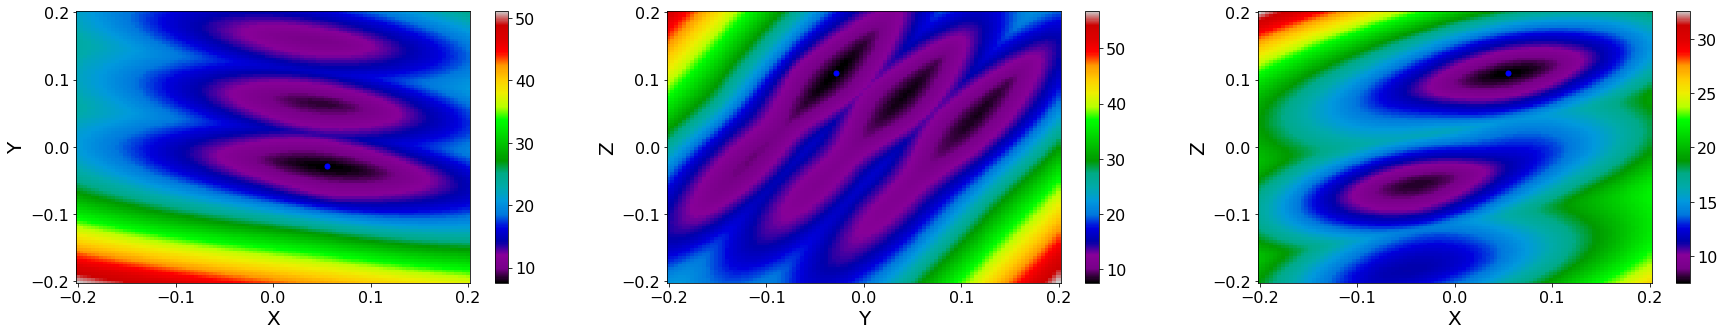

In [13]:
%matplotlib inline
idx = idx
#idx= -2
P=ZFP[idx]



Bxi = np.linspace(-0.2,0.2,pts)
X,Y = np.meshgrid(Bxi,Bxi)
Fxy,_,_=sweep(np.array(np.meshgrid(Bxi,Bxi,P[2])).reshape(3,-1).T)
Fxy= np.squeeze(np.real(Fxy[:,t].T.reshape(pts,pts,-1)))
Fyz,_,_=sweep(np.array(np.meshgrid(P[0],Bxi,Bxi)).reshape(3,-1).T)
Fyz= np.squeeze(np.real(Fyz[:,t].T.reshape(pts,pts,-1)))
Fxz,_,_=sweep(np.array(np.meshgrid(Bxi,P[1],Bxi)).reshape(3,-1).T)
Fxz= np.squeeze(np.real(Fxz[:,t].T.reshape(pts,pts,-1)))



print("Fr",fr.shape)



fig = plt.figure(figsize=(30,5))
plt.set_cmap('nipy_spectral')

marker_style = dict(color='b', marker='o',
                    markersize=5)

ax = plt.subplot(1,3,1)
plt.pcolor(X,Y,Fxy,cmap='nipy_spectral',shading='auto')
plt.plot(P[0],P[1],**marker_style)
plt.xlabel("X")
plt.ylabel("Y")
plt.colorbar()

ax = plt.subplot(1,3,2)
plt.pcolor(X,Y,Fyz.T,cmap='nipy_spectral',shading='auto')
plt.plot(P[1],P[2],**marker_style)
plt.xlabel("Y")
plt.ylabel("Z")
plt.colorbar()

ax = plt.subplot(1,3,3)
plt.pcolor(X,Y,Fxz.T,cmap='nipy_spectral',shading='auto')
plt.plot(P[0],P[2],**marker_style)
plt.xlabel("X")
plt.ylabel("Z")

plt.colorbar()

#for i in range(int(Fi.shape[3]/4)):
#ax.plot_surface(X,Y,np.real(Fi[:,:,Z,T]))



#plt.legend()
plt.savefig("Pr_ZF.png")
plt.show()
plt.close()
